In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

In [2]:
# --- Step 1: Load the WAV files ---
file1 = 'recordings\i2s1.wav'  # replace with first file path
file2 = 'recordings\i2s2.wav'  # replace with second file path

Fs1, y1 = wavfile.read(file1)
Fs2, y2 = wavfile.read(file2)

In [3]:
# --- Step 2: Convert to mono if stereo ---
if y1.ndim > 1:
    y1 = y1.mean(axis=1)
if y2.ndim > 1:
    y2 = y2.mean(axis=1)


In [4]:
# --- Step 3: FFT calculation ---
def compute_fft(y, Fs):
    N = len(y)
    t = np.arange(N)/Fs
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=1/Fs)
    P2 = np.abs(Y/N)
    P1 = P2[:N//2]*2
    f1 = f[:N//2]
    return t, y, f1, P1

t1, y1, f1, P1 = compute_fft(y1, Fs1)
t2, y2, f2, P2 = compute_fft(y2, Fs2)

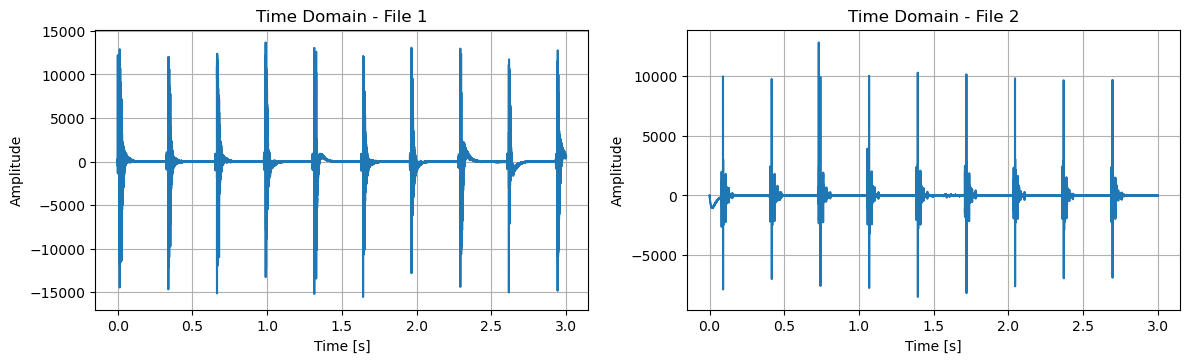

In [5]:
# --- Step 4: Plot time-domain signals ---
plt.figure(figsize=(14,8))
plt.subplot(2,2,1)
plt.plot(t1, y1)
plt.title('Time Domain - File 1')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(t2, y2)
plt.title('Time Domain - File 2')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

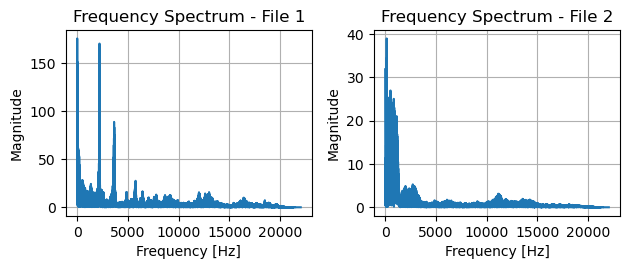

In [6]:
# --- Step 5: Plot frequency spectra ---
plt.subplot(2,2,3)
plt.plot(f1, P1)
plt.title('Frequency Spectrum - File 1')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(f2, P2)
plt.title('Frequency Spectrum - File 2')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# --- Step 6: Play audio files ---
print("Playing File 1:")
display(Audio(y1, rate=Fs1))
print("Playing File 2:")
display(Audio(y2, rate=Fs2))

Playing File 1:


Playing File 2:


In [8]:
# --- Step 7: Frequency characteristics ---
def frequency_characteristics(frequencies, magnitude):
    dominant_freq = frequencies[np.argmax(magnitude)]
    mean_freq = np.sum(frequencies * magnitude) / np.sum(magnitude)
    bandwidth = frequencies[np.where(magnitude > (0.5 * np.max(magnitude)))][[-1]][0] - frequencies[np.where(magnitude > (0.5 * np.max(magnitude)))][0]
    return dominant_freq, mean_freq, bandwidth

dom1, mean1, bw1 = frequency_characteristics(f1, P1)
dom2, mean2, bw2 = frequency_characteristics(f2, P2)

print(f"\nFrequency characteristics of File 1:")
print(f"Dominant Frequency: {dom1:.2f} Hz")
print(f"Mean Frequency: {mean1:.2f} Hz")
print(f"Approximate Bandwidth: {bw1:.2f} Hz")

print(f"\nFrequency characteristics of File 2:")
print(f"Dominant Frequency: {dom2:.2f} Hz")
print(f"Mean Frequency: {mean2:.2f} Hz")
print(f"Approximate Bandwidth: {bw2:.2f} Hz")


Frequency characteristics of File 1:
Dominant Frequency: 13.67 Hz
Mean Frequency: 6656.94 Hz
Approximate Bandwidth: 3645.00 Hz

Frequency characteristics of File 2:
Dominant Frequency: 147.33 Hz
Mean Frequency: 4705.03 Hz
Approximate Bandwidth: 1129.67 Hz
